# 0. 准备环境与数据

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 0.1 设置绘图风格

In [35]:
# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

## 0.2 从网络读取泰坦尼克号数据集

In [36]:
# 从网络读取泰坦尼克号数据集
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

## 0.3 查看数据概览

In [37]:
# 查看数据概览
print("数据集形状:", df.shape)
print("\n前5行数据:")
display(df.head())

print("\n数据类型与缺失值情况:")
print(df.info())

数据集形状: (891, 12)

前5行数据:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



数据类型与缺失值情况:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# 1. 数据集划分

In [38]:
## 导入第三方库
from sklearn.model_selection import train_test_split

## 1.1 定义特征和标签

In [39]:
# 定义特征 X 和目标标签 y (Survived)
X = df.drop('Survived', axis=1)
y = df['Survived']

In [40]:
# 划分训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,       # 固定随机种子，保证可复现
    stratify=y             # 分层抽样，保持正负样本比例一致
)

设置 `stratify = y` 后，`sklearn` 会确保两者中正负样本比例与原始数据保持一致。
接下来所有探索和规则制定必须只在 `X_train` 上进行！

In [41]:

print(f"训练集: {X_train.shape[0]} 样本")  # 712
print(f"测试集: {X_test.shape[0]} 样本")   # 179
print(f"\n训练集存活率: {y_train.mean():.2%}")  # ≈38.34%
print(f"测试集存活率: {y_test.mean():.2%}")     # ≈38.55%

训练集: 712 样本
测试集: 179 样本

训练集存活率: 38.34%
测试集存活率: 38.55%


# 2. 数据探索分析 (EDA)

## 2.1 基本信息

### 数据集类型

In [42]:
# 查看训练集数据类型和缺失情况
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


### 缺失值统计

In [43]:
# 缺失值统计
missing = X_train.isnull().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
pd.DataFrame({"缺失数": missing, "缺失率%": missing_pct}).query("缺失数 > 0")

,缺失数,缺失率%
Age,137,19.2
Cabin,552,77.5
Embarked,2,0.3


## 2.2 数值特征统计

In [44]:
X_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,575.000000,712.000000,712.000000,712.000000
mean,444.405899,2.308989,29.807687,0.492978,0.390449,31.819826
std,257.465527,0.833563,14.485211,1.060720,0.838134,48.059104
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,439.500000,3.000000,28.500000,0.000000,0.000000,14.454200
75%,667.250000,3.000000,39.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


注意 Fare 最大 512，最小 0，量纲差异巨大，后面需要缩放。

## 2.3 数据可视化

使用 Matplotlib 和 seaborn 对数据进行可视化，看出更多端倪

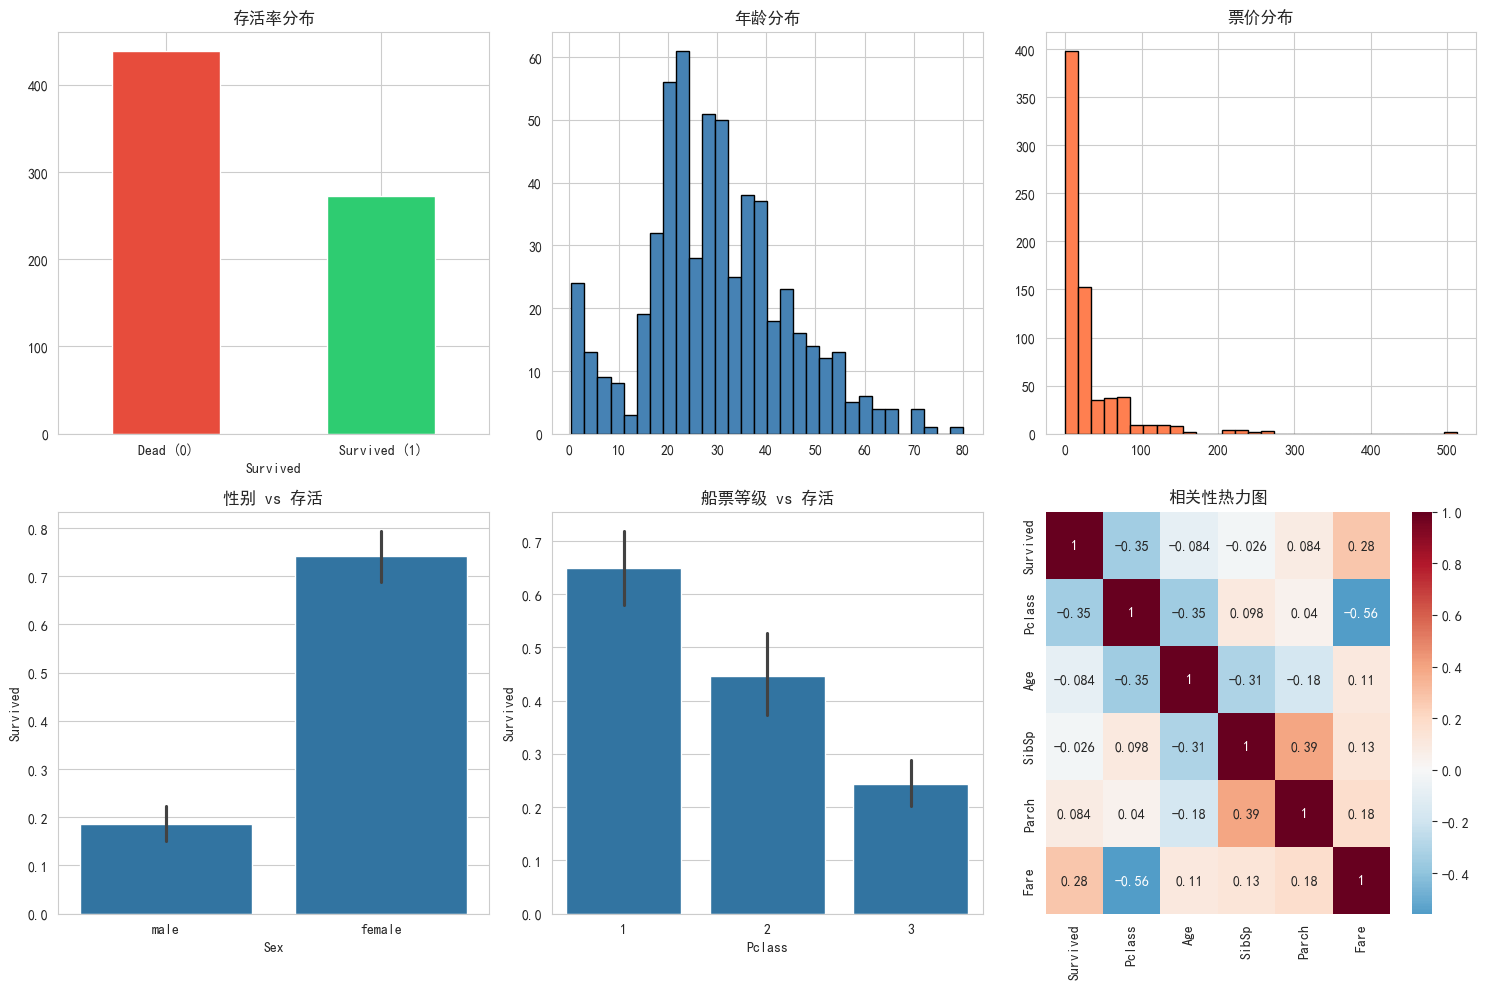

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 存活率分布
y_train.value_counts().plot.bar(ax=axes[0,0], color=['#e74c3c','#2ecc71'])
axes[0,0].set_title('存活率分布')
axes[0,0].set_xticklabels(['Dead (0)', 'Survived (1)'], rotation=0)

# 2. 年龄分布
X_train['Age'].hist(bins=30, ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('年龄分布')

# 3. 票价分布
X_train['Fare'].hist(bins=30, ax=axes[0,2], color='coral', edgecolor='black')
axes[0,2].set_title('票价分布')

# 4. 性别 vs 存活
train_data = X_train.copy()
train_data['Survived'] = y_train
sns.barplot(x='Sex', y='Survived', data=train_data, ax=axes[1,0])
axes[1,0].set_title('性别 vs 存活')

# 5. 船票等级 vs 存活
sns.barplot(x='Pclass', y='Survived', data=train_data, ax=axes[1,1])
axes[1,1].set_title('船票等级 vs 存活')

# 6. 相关性热力图
numeric_cols = train_data[['Survived','Pclass','Age','SibSp','Parch','Fare']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='RdBu_r', center=0, ax=axes[1,2])
axes[1,2].set_title('相关性热力图')

plt.tight_layout()
plt.show()

## 2.4 EDA 关键发现

| 发现                               | 处理                      |
| -------------------------------- | ----------------------- |
| 女性存活率远高于男性（~74% vs ~19%）         | Sex 是强特征，需编码为数值         |
| 一等舱存活率最高（~63%）                   | Pclass 是强特征，考虑保留或独热编码   |
| Age 缺失约 20%                      | 需要填充，分布略偏态，选用中位数        |
| Cabin 缺失 77%                     | 直接填充意义不大，考虑转化为"有/无客舱信息" |
| Fare 严重右偏（均值 > 中位数，长尾分布）         | 可能需要对数变换或截断处理           |
| PassengerId、Name、Ticket 对预测无直接帮助 | 考虑删除，或从 Name 中提取有用信息    |

# 3. 数据清洗

## 3.1 处理重复值

### 检查重复行

In [46]:
# 检查重复行
duplicates = X_train.duplicated().sum()
print(f"重复行数: {duplicates}")


重复行数: 0


### 处理重复行

In [47]:
# 如果有重复行
if duplicates > 0:
    X_train = X_train.drop_duplicates()
    y_train = y_train[X_train.index]  # 保持 y 与 X 同步

## 3.2 处理缺失值

当数据集中出现缺失值时，处理策略需根据缺失比例及特征类型灵活选择

### 按缺失比例决定删除策略

- 缺失极低（< 5%）且为随机缺失
  
  直接删除对应样本行
- 缺失极高（> 70%）
  
  该特征信息量匮乏，通常直接删除整列

### 按特征类型选择填充方法

- 数值型特征：

  用均值或中位数填充。
  
  均值适用于正态分布且无异常值的场景；
  
  中位数对极端值不敏感，在数据偏态或存在异常值时更加稳健
- 类别型特征：
  
  用众数填充，或新增 "Unknown" 类别。
  
  众数填充适合低缺失率场景；
  
  将缺失独立标记为 "Unknown" 则能保留"缺失本身可能蕴含的业务信息

### sklearn.SimpleImputer()

`sklearn` 提供了 `SimpleImputer` 工具类处理缺失值。

它可以扫描数据列，发现空缺后，根据设定的 `strategy`，自动计算一个值填进去

1. 初始化时设置 `strategy`
2. 在训练集上调用 `.fit()` 算出均值/中位数/众数，保存在对象内部
3. 在测试集/新数据上调用 `.transform()`：将保存的数据进行填充

In [48]:
from sklearn.impute import SimpleImputer

### 填充中位数

In [49]:
# ── Age: 中位数填充（因为 Age 分布略有偏态）──
age_imputer = SimpleImputer(strategy='median')
# fit 只用训练集！
age_imputer.fit(X_train[['Age']])
print(f"训练集 Age 中位数: {age_imputer.statistics_[0]}")  # 28.0

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age']  = age_imputer.transform(X_test[['Age']]).ravel()  # 用训练集的中位数！


训练集 Age 中位数: 28.5


### 填充众数

In [50]:
# ── Embarked: 众数填充（只缺 2 个）──
embarked_imputer = SimpleImputer(strategy='most_frequent')
embarked_imputer.fit(X_train[['Embarked']])
print(f"训练集 Embarked 众数: {embarked_imputer.statistics_[0]}")  # 'S'

X_train['Embarked'] = embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked']  = embarked_imputer.transform(X_test[['Embarked']]).ravel()


训练集 Embarked 众数: S


### 填充转化值再删除

In [51]:
# ── Cabin: 缺失 77%，先转化为"有无客舱信息"，再删除原列 ──
X_train['HasCabin'] = X_train['Cabin'].notna().astype(int)
X_test['HasCabin']  = X_test['Cabin'].notna().astype(int)

X_train.drop(columns=['Cabin'], inplace=True)
X_test.drop(columns=['Cabin'], inplace=True)


### 验证

In [52]:
# 验证
print("\n处理后缺失值:")
print(X_train.isnull().sum())



处理后缺失值:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


## 3.3 处理异常值

异常值（Outliers）是指数据中显著偏离其他观测值的极端值。

它们可能是由于测量误差、数据录入错误或真实的极端情况产生的。可以使用箱线图检测异常值

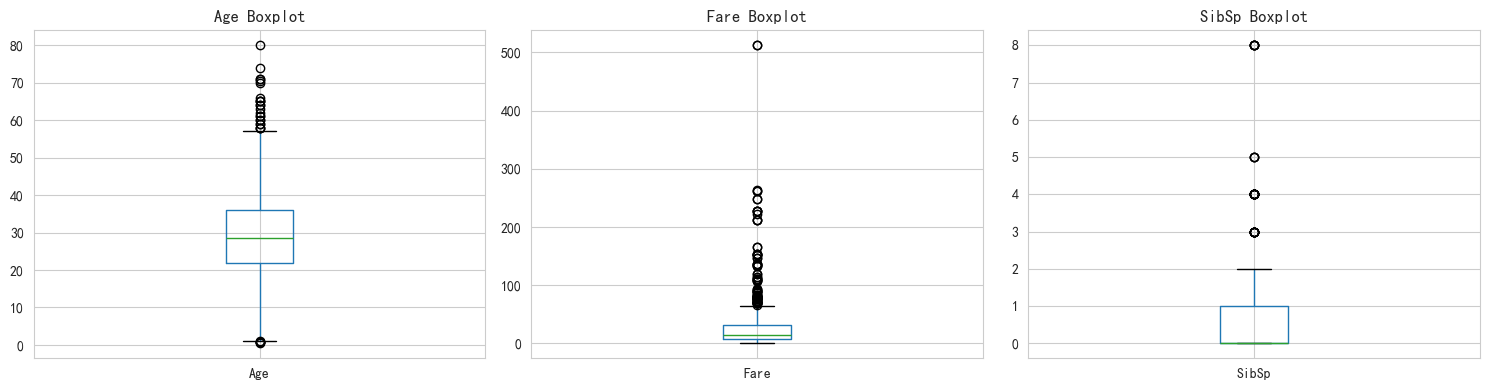

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Age', 'Fare', 'SibSp']):
    X_train.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

### 分析异常特征

1. Age (年龄)
  - 大部分乘客集中在 20-40 岁之间（箱体部分）。
  - 但在 60-80 岁之间有很多离群点。这说明船上有不少高龄乘客，虽然人数少，但他们是真实存在的，不是数据错误。
2. Fare (票价)
  - 极度右偏。绝大多数人的票价非常低（箱体被压扁在底部，接近 0-50 美元）。
  - 但是有极少数人的票价高得离谱，超过 500 美元！这些可能是一等舱乘客。
  - 对模型的影响：这种巨大的差异会让模型难以训练，如果不处理（比如取对数 log 或分箱），模型可能会过度关注这几个高价票的人，而忽略了普通大众。
3. SibSp (兄弟姐妹/配偶数)
  - 大部分人都是 0 或 1，独自旅行或夫妻同行。
  - 但也有一些大家庭，带着 3、4、5 甚至 8 个亲属，这也是真实的异常值。

### 处理异常数据

我们使用统计学方法（IQR）识别并处理票价（Fare）中的极端异常值，防止它们干扰机器学习模型的训练。

不必直接删除这些异常数据，采用截断的策略，将过高的票价强行拉回到合理范围内即可。

In [54]:
# 用 IQR 方法检测
def detect_outliers_iqr(data, column, factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - factor * IQR)
    upper = Q3 + factor * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f"{column}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  合理范围: [{lower:.1f}, {upper:.1f}]")
    print(f"  异常值数量: {len(outliers)} ({len(outliers)/len(data):.1%})")
    return lower, upper

lower, upper = detect_outliers_iqr(X_train, 'Fare')

# 对于 Fare，我们选择截断而非删除
# 因为高票价可能是真实的，头等舱确实很贵
X_train['Fare'] = X_train['Fare'].clip(lower=lower, upper=upper)
X_test['Fare']  = X_test['Fare'].clip(lower=lower, upper=upper)

Fare: Q1=7.9, Q3=31.0, IQR=23.1
  合理范围: [0.0, 65.7]
  异常值数量: 91 (12.8%)


# 4. 编码特征

=== 原始数据 ===
|idx|survived|sex|pclass|embark_town|
|:---|--------:|------:|:------:|-----------|
|0|0|male|3|Southampton|
|1|1|female|1|Cherbourg|
|2|1|female|3|Southampton|
|3|1|female|1|Southampton|
|4|0|male|3|Southampton|

## 4.1 序数编码 Ordinal Encoding

对 Titannic 的 Fare 数据做下处理

1等舱 > 2等舱 > 3等舱

`sklearn` 的 `OrdinalEncoder` 工具类默认按字母顺序或出现顺序

手动指定 `categories` 以保证逻辑正确

pclass 本身已经是数字 `1, 2, 3`

为了演示效果，构造一个模拟 "等级" 列：`['Low', 'Mid', 'High']`

In [55]:
from sklearn.preprocessing import OrdinalEncoder

df_ordinal = df.copy()
df_ordinal['fare_category'] = pd.cut(df['Fare'], bins=3, labels=['Low', 'Mid', 'High'])

oe = OrdinalEncoder(categories=[['Low', 'Mid', 'High']]) # 显式指定顺序
df_ordinal['fare_cat_encoded'] = oe.fit_transform(df_ordinal[['fare_category']])

print(f"顺序定义: Low < Mid < High -> 0, 1, 2")
print(df_ordinal[['fare_category', 'fare_cat_encoded']].head())

顺序定义: Low < Mid < High -> 0, 1, 2
  fare_category  fare_cat_encoded
0           Low               0.0
1           Low               0.0
2           Low               0.0
3           Low               0.0
4           Low               0.0


## 4.2 独热编码 One-Hot Encoding

采用独热编码处理 embark_town



In [56]:
df_ohe = df.copy()
df_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [57]:
df_ohe.Embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

原生数据集内不包含列 embark_town

根据列 Embarked 补充列 embark_town

映射关系：
- 'C' -> 'Cherbourg'
- 'Q' -> 'Queenstown'
- 'S' -> 'Southampton'


In [58]:
df_ohe['embark_town'] = df_ohe['Embarked'].map({'S': 'Southampton','C': 'Cherbourg','Q': 'Queenstown'})
df_ohe.embark_town.unique()

array(['Southampton', 'Cherbourg', 'Queenstown', nan], dtype=object)

In [59]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
ohe

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [60]:
# 注意：输入必须是二维数组，所以用 [['embark_town']]
ohe_result = ohe.fit_transform(df_ohe[['embark_town']])
ohe_result

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]], shape=(891, 4))

In [61]:
# 获取生成的列名 (例如: embark_town_Cherbourg)
ohe_columns = ohe.get_feature_names_out(['embark_town'])
ohe_columns

array(['embark_town_Cherbourg', 'embark_town_Queenstown',
       'embark_town_Southampton', 'embark_town_nan'], dtype=object)

In [62]:
# 转换为 DataFrame 以便合并
ohe_df = pd.DataFrame(ohe_result, columns = ohe_columns, index = df_ohe.index)
ohe_df.head()

,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,embark_town_nan
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


In [63]:
# 将独热编码列拼接到主表，并删除原始文本列
df_final = pd.concat([df_ohe.drop('embark_town', axis=1), ohe_df], axis=1)
df_final.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,embark_town_nan
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0,0.0,1.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1.0,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0,0.0,1.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.0,0.0,1.0,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0,0.0,1.0,0.0


In [64]:
print("\n=== One-Hot Encoding 演示 (Embark Town) ===")
print(f"生成的新列: {list(ohe_df.columns)}")
print(df_final.head())


=== One-Hot Encoding 演示 (Embark Town) ===
生成的新列: ['embark_town_Cherbourg', 'embark_town_Queenstown', 'embark_town_Southampton', 'embark_town_nan']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  embark_town_Cherbourg  \
0      0         A/5 21171   7.2500   NaN        S                    0.0   
1      0          

In [65]:
# from sklearn.preprocessing import OneHotEncoder

# df_ohe = df.copy()

# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# # 注意：输入必须是二维数组，所以用 [['embark_town']]
# ohe_result = ohe.fit_transform(df_ohe[['embark_town']])

# # 获取生成的列名 (例如: embark_town_Cherbourg)
# ohe_columns = ohe.get_feature_names_out(['embark_town'])

# # 转换为 DataFrame 以便合并
# ohe_df = pd.DataFrame(ohe_result, columns=ohe_columns, index=df_ohe.index)

# # 将独热编码列拼接到主表，并删除原始文本列
# df_final = pd.concat([df_ohe.drop('embark_town', axis=1), ohe_df], axis=1)

# print("\n=== One-Hot Encoding 演示 (Embark Town) ===")
# print(f"生成的新列: {list(ohe_df.columns)}")
# print(df_final.head())

## 4.3 标签编码 Label Encoding

采用标签编码处理 sex

In [66]:
from sklearn.preprocessing import LabelEncoder

# 性别是二分类特征，可以使用标签编码
le = LabelEncoder()
X_train_encoded = X_train.copy()
X_train_encoded['Sex'] = le.fit_transform(X_train['Sex']) # male=1, female=0

# 5. 特征构造与删除

In [67]:
X_train_fe = X_train.copy()
X_train_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          712 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Embarked     712 non-null    object 
 10  HasCabin     712 non-null    int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 66.8+ KB


## 5.1 合并特征

将分散的亲属数量合并为“家庭规模”，并标记出“独自一人”的乘客，因为家庭结构可能直接影响逃生策略。

In [68]:
# 1. 家族大小
X_train_fe['family_size'] = X_train_fe['SibSp'] + X_train_fe['Parch'] + 1
X_train_fe[['SibSp', 'Parch', 'family_size']].head()

,SibSp,Parch,family_size
692,0,0,1
481,0,0,1
527,0,0,1
855,0,1,2
801,1,1,3


## 5.2 提取信息

从看似无用的姓名中提取出头衔（如 Mr, Mrs, Master），这能帮我们识别出社会地位和特殊群体。

In [69]:
# 2. 是否独自一人
X_train_fe['is_alone'] = (X_train_fe['family_size'] == 1).astype(int)
X_train_fe[['family_size', 'is_alone']].head()

,family_size,is_alone
692,1,1
481,1,1
527,1,1
855,2,0
801,3,0


In [70]:
# 由于抽样得到 X_train 每次各不相同，因此 Name 中包含的头衔不尽相同
df_title = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand = False).unique()
print(f"\n Titles in raw data:\n{df_title}\nlength: {len(df_title)}")
train_title = X_train_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand = False).unique()
print(f"\n Titles in train data:\n{train_title}\nlength: {len(train_title)}")


 Titles in raw data:
['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
length: 17

 Titles in train data:
['Mr' 'Mrs' 'Col' 'Miss' 'Rev' 'Major' 'Master' 'Dr' 'Mlle' 'Lady' 'Sir'
 'Ms' 'Jonkheer' 'Don']
length: 14


|No.|Title|头衔|含义|
|:---|:--------|:-----:|------------:|
|01|Capt|上尉|海军上校Captain|
|02|Col|上校|陆军上校Colonel|
|03|Countess|女伯爵||
|04|Don|阁下||
|05|Dona|女士|小姐太太夫人|
|06|Dr|博士|Doctor|
|07|Jonkheer|勋爵|荷兰贵族头衔|
|08|Lady|小姐||
|09|Major|少校||
|10|Master|硕士||
|11|Miss|女士||
|12|Mlle|小姐|Mademoiselle|
|13|Mr|先生|Mister|
|14|Mrs|夫人|Mistress|
|15|Ms|女士|Miss/Mrs.|
|16|Rev|牧师|Reverend|
|17|Sir|爵士||

In [71]:
# 3. 处理头衔
## 从姓名提取头衔 (Mr, Mrs, Miss, Master, ...)
X_train_fe['title'] = X_train_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand = False)
## 归并稀有头衔为 Rare
X_train_fe['title'] = X_train_fe['title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
## 归并女士头衔为 Miss
X_train_fe['title'] = X_train_fe['title'].replace('Mlle', 'Miss')
X_train_fe['title'] = X_train_fe['title'].replace('Ms', 'Miss')
## 归并夫人头衔为 Mrs
X_train_fe['title'] = X_train_fe['title'].replace('Mme', 'Mrs')

In [72]:
X_train_fe.title.unique()

array(['Mr', 'Mrs', 'Rare', 'Miss', 'Master'], dtype=object)

## 5.3 删减噪音

果断删除那些缺失太多、格式混乱或者会导致数据泄露的列，只保留最核心的特征。

In [73]:
# 4. 删除无用特征
X_train_fe.info()
drop_cols = ['name', 'ticket', 'cabin', 'deck', 'alive', 'adult_male', 'who', 'class', 'embark_town']
X_train_fe = X_train_fe.drop(columns = [c for c in drop_cols if c in X_train_fe.columns])

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          712 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Embarked     712 non-null    object 
 10  HasCabin     712 non-null    int64  
 11  family_size  712 non-null    int64  
 12  is_alone     712 non-null    int64  
 13  title        712 non-null    object 
dtypes: float64(2), int64(7), object(5)
memory usage: 83.4+ KB


In [74]:
X_train_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          712 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Embarked     712 non-null    object 
 10  HasCabin     712 non-null    int64  
 11  family_size  712 non-null    int64  
 12  is_alone     712 non-null    int64  
 13  title        712 non-null    object 
dtypes: float64(2), int64(7), object(5)
memory usage: 83.4+ KB


## 5.4 测试集内套用

In [75]:
def t(df):
    df = df.copy()

    # 1. 家族大小
    # df['family_size'] = df['SibSp'] + df['Parch'] + 1

    # 2. 是否独自一人
    # df['is_alone'] = (df['family_size'] == 1).astype(int)

    # 3. 从姓名提取头衔 (Mr, Mrs, Miss, Master 等)
    tmp = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    print(f"\n{tmp.unique()}")
    # df['title'] = tmp.map({['Mme', 'Mrs']: 'Mrs', ['Ms', 'Mlle', 'Miss']: 'Miss', 'Mr':'Mr'})
    df['title'] = tmp.map({'Mme': 'Mrs', 'Mrs': 'Mrs', 'Ms':'Miss', 'Mlle':'Miss', 'Miss': 'Miss', 'Mr':'Mr'}).fillna('Rare')
    # 归并稀有头衔
    # df['title'] = df['title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 
    #                                    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    # df['title'] = df['title'].replace('Mlle', 'Miss')
    # df['title'] = df['title'].replace('Ms', 'Miss')
    # df['title'] = df['title'].replace('Mme', 'Mrs')

    # 4. 删除无用特征
    # drop_cols = ['name', 'ticket', 'cabin', 'deck', 'alive', 'adult_male', 'who', 'class', 'embark_town']
    # df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df

t_train = t(X_train)
t_test = t(X_test)

# print("新增特征后形状:", X_train_fe.shape)
# print(X_train_fe[['family_size', 'is_alone', 'title']].head())


['Mr' 'Mrs' 'Col' 'Miss' 'Rev' 'Major' 'Master' 'Dr' 'Mlle' 'Lady' 'Sir'
 'Ms' 'Jonkheer' 'Don']

['Mr' 'Miss' 'Mrs' 'Major' 'Mme' 'Master' 'Capt' 'Countess' 'Dr' 'Rev']


In [76]:
t_train.title.unique()

array(['Mr', 'Mrs', 'Rare', 'Miss'], dtype=object)

In [77]:
t_train.title.unique()

array(['Mr', 'Mrs', 'Rare', 'Miss'], dtype=object)

In [78]:
def create_features(df):
    df = df.copy()

    # 1. 家族大小
    df['family_size'] = df['SibSp'] + df['Parch'] + 1

    # 2. 是否独自一人
    df['is_alone'] = (df['family_size'] == 1).astype(int)

    # 3. 从姓名提取头衔 (Mr, Mrs, Miss, Master 等)
    df['title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    # 归并稀有头衔
    df['title'] = df['title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 
                                       'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['title'] = df['title'].replace('Mlle', 'Miss')
    df['title'] = df['title'].replace('Ms', 'Miss')
    df['title'] = df['title'].replace('Mme', 'Mrs')

    # 4. 删除无用特征
    drop_cols = ['name', 'ticket', 'cabin', 'deck', 'alive', 'adult_male', 'who', 'class', 'embark_town']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df

X_train_fe = create_features(X_train)
X_test_fe = create_features(X_test)

print("新增特征后形状:", X_train_fe.shape)
print(X_train_fe[['family_size', 'is_alone', 'title']].head())

新增特征后形状: (712, 14)
     family_size  is_alone title
692            1         1    Mr
481            1         1    Mr
527            1         1    Mr
855            2         0   Mrs
801            3         0   Mrs


# 6. 特征缩放

## 6.1 标准化

$$ z = \cfrac {x - \mu} {\sigma}$$

In [79]:
from sklearn.preprocessing import StandardScaler

# 选取需要缩放的数值型列 (例如 'Age' 和 'Fare')
numeric_cols = ['Age', 'Fare'] 

# 标准化
scaler = StandardScaler()

# 只在训练集上 fit，获取均值和标准差
scaler.fit(X_train[numeric_cols])

# 用相同的参数转换训练集和测试集
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("标准化完成")
print(X_train_scaled[numeric_cols].head())

print(f"\n均值检查 (应接近0): {X_train_scaled[numeric_cols].mean().values}")
print(f"标准差检查 (应接近1): {X_train_scaled[numeric_cols].std().values}")

标准化完成
          Age      Fare
692 -0.081135  1.587313
481 -0.081135 -1.168780
527 -0.081135  2.034199
855 -0.887827 -0.712650
801  0.110934  0.111801

均值检查 (应接近0): [7.73413792e-17 1.90858565e-16]
标准差检查 (应接近1): [1.00070299 1.00070299]


## 6.2 归一化

$$x' = \cfrac {x - x_{min}} {x_{max} - x_{min}}$$

# 7. 工程实践

前面的步骤虽然清晰，但手动操作容易出错且难以维护。
`sklearn` 提供提供了 `Pipeline` 把整个流程串起来，用 `ColumnTransformer` 对不同类型列做不同处理。

1. 防止数据泄露：自动保证 fit 只在训练集，transform 应用到测试集。
2. 代码简洁：将预处理和模型封装在一起。
3. 便于部署：保存一个 Pipeline 对象即可用于生产环境预测。

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 重新加载干净的原始划分数据（为了演示 Pipeline）
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Survived', axis=1), 
    df['Survived'], 
    test_size=0.2, random_state=42
)

# 定义我们要处理的列
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass'] # Pclass虽是数字，但其实是类别(1,2,3等舱)

# 1. 为数值列创建流水线：先填补缺失值 -> 再做标准化
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. 为类别列创建流水线：先填补缺失值 -> 再做独热编码
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # 忽略测试集中没见过的新类别
])

# 3. 使用 ColumnTransformer 将两条流水线组合起来
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. 一键处理！
# fit_transform 训练集
X_train_ready = preprocessor.fit_transform(X_train)
# transform 测试集
X_test_ready = preprocessor.transform(X_test)

print("预处理流水线搭建成功！生成的矩阵形状:", X_train_ready.shape)

预处理流水线搭建成功！生成的矩阵形状: (712, 9)


In [81]:
X_train_ready[:5]  # 查看前5行

array([[ 1.25364106, -0.07868358, -0.47072241, -0.47934164,  1.        ,
         0.        ,  1.        ,  0.        ,  0.        ],
       [-0.47728355, -0.37714494, -0.47072241, -0.47934164,  1.        ,
         0.        ,  1.        ,  1.        ,  0.        ],
       [ 0.21508629, -0.47486697, -0.47072241, -0.47934164,  1.        ,
         0.        ,  1.        ,  0.        ,  1.        ],
       [-0.24649361, -0.47623026,  0.37992316, -0.47934164,  1.        ,
         0.        ,  1.        ,  0.        ,  1.        ],
       [-1.78509326, -0.02524937,  2.93185988,  2.04874166,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ]])